## Load the data

In [1]:
import pandas as pd
import json
import os
import numpy as np; np.random.seed(42)
from glob import glob
from tqdm import tqdm
import seaborn as sns
import pdb

import sys; sys.path.append('..')

import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc('pdf', fonttype=42)
matplotlib.rc('ps', fonttype=42)

params = {'mathtext.default': 'regular' }          
plt.rcParams.update(params)

sns.set(font_scale=1.25, style='whitegrid')
sns.set(palette='magma')
sns.set_style("whitegrid")

rdir  = '../../results/black-box-tuning/'
figdir = f'../figs/black-box-tuning/'
datadir = '../../datasets/blackbox/' # Set to path to datasets

def save(name='tmp',h=None):
    name = name.strip().replace(' ','-').replace('%','pct')
    if h == None:
        h = plt.gcf()

    h.tight_layout()

    print('saving',figdir+'/'+name+'.pdf')

    if not os.path.exists(figdir):
        os.makedirs(figdir)

    plt.savefig(figdir+'/'+name+'.pdf', bbox_inches='tight')
    plt.savefig(figdir+'/'+name+'.png', bbox_inches='tight')


In [2]:
df_eco2ai = pd.read_feather(rdir+'power_consumption.feather')
df_eco2ai['start_time'] = pd.to_datetime(df_eco2ai['start_time'])

print(df_eco2ai.info())

df_eco2ai.sample().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9527 entries, 0 to 9526
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   dataset                 9527 non-null   object        
 1   algorithm               9527 non-null   object        
 2   random_state            9527 non-null   int64         
 3   start_time              9527 non-null   datetime64[ns]
 4   experiment_description  9527 non-null   object        
 5   duration(s)             8331 non-null   float64       
 6   power_consumption(kWh)  8331 non-null   float64       
 7   CO2_emissions(kg)       8331 non-null   float64       
 8   CPU_name                9527 non-null   object        
 9   GPU_name                9527 non-null   object        
 10  cost                    8331 non-null   float64       
 11  symbolic_alg            9527 non-null   bool          
 12  pre_trained             9527 non-null   bool    

,1087
dataset,1089_USCrime
algorithm,E2E
random_state,11964
start_time,2025-04-19 23:39:03
experiment_description,tunede2et 11964
duration(s),10.45582
power_consumption(kWh),0.000022
CO2_emissions(kg),0.000008
CPU_name,Intel(R) Xeon(R) Gold 6342 CPU @ 2.80GHz/2 dev...
GPU_name,0 device(s)


In [3]:
# even if the job is killed due to max_time the eco2AI will save the info
# (the file is generated before the experiment is fully finished).
# Here we keep only the last execution:
print(df_eco2ai.shape)
df_eco2ai = df_eco2ai.sort_values(['algorithm', 'dataset', 'random_state', 'start_time'])\
                     .drop_duplicates(subset=['algorithm', 'dataset', 'random_state'], keep='last')
print(df_eco2ai.shape)

(9527, 14)
(7427, 14)


In [4]:
print('mean trial count:')
print(df_eco2ai.groupby('algorithm')['dataset'].count().sort_values()
      / df_eco2ai.dataset.nunique())

mean trial count:
algorithm
NeSymRes           5.666667
TPSR               6.666667
AFP_FE            14.250000
FEAT              20.416667
EPLEX             25.000000
AFP_EHC           25.000000
TIR               25.166667
AFP               25.166667
E2E               27.000000
PYSR              27.500000
ITEA              28.416667
PS-Tree           28.833333
Rils-Rols         29.833333
Bingo             30.000000
BSR               30.000000
Brush             30.000000
GPZGD             30.000000
Genetic Engine    30.000000
FFX               30.000000
GP-GOMEA          30.000000
EQL               30.000000
Operon            30.000000
QLattice          30.000000
gplearn           30.000000
Name: dataset, dtype: float64


In [5]:
# Total experiment consumption
print(df_eco2ai['power_consumption(kWh)'].sum())
print(df_eco2ai['CO2_emissions(kg)'].sum())

7.814013988710249
2.8878329638216353


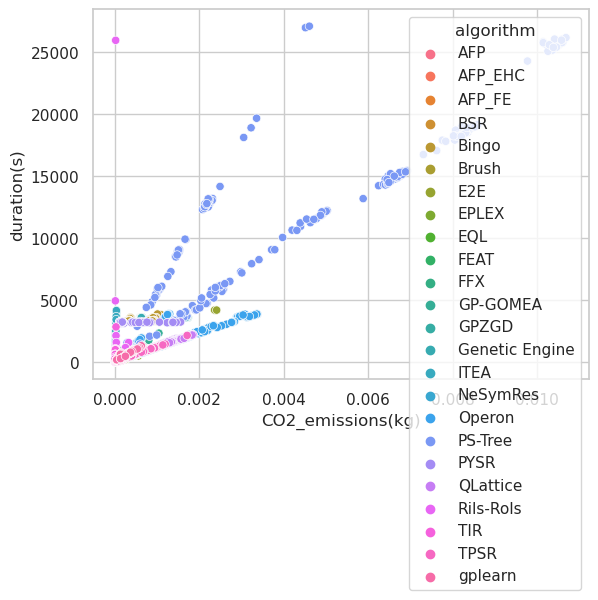

In [6]:
sns.scatterplot(data=df_eco2ai, y='duration(s)', x='CO2_emissions(kg)', hue='algorithm')
plt.show()

/tmp/ipykernel_597571/236132223.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order = df_eco2ai.groupby('algorithm').mean() \
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slic

saving ../figs/black-box-tuning//CO2_emissions(kg).pdf


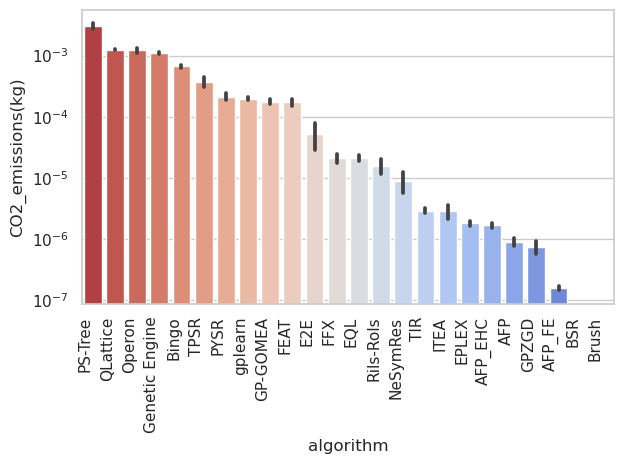

In [7]:
order = df_eco2ai.groupby('algorithm').mean() \
              .sort_values('CO2_emissions(kg)', ascending=False).index
              
sns.barplot(data=df_eco2ai, x='algorithm', y='CO2_emissions(kg)', order=order, palette='coolwarm_r')
plt.xticks(rotation=90, ha='right')
plt.yscale('log')
save('CO2_emissions(kg)')
plt.show()

/tmp/ipykernel_597571/2303608581.py:8: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order = df_eco2ai_filter.groupby('algorithm').median() \
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


saving ../figs/black-box-tuning//power_consumption(kWh).pdf


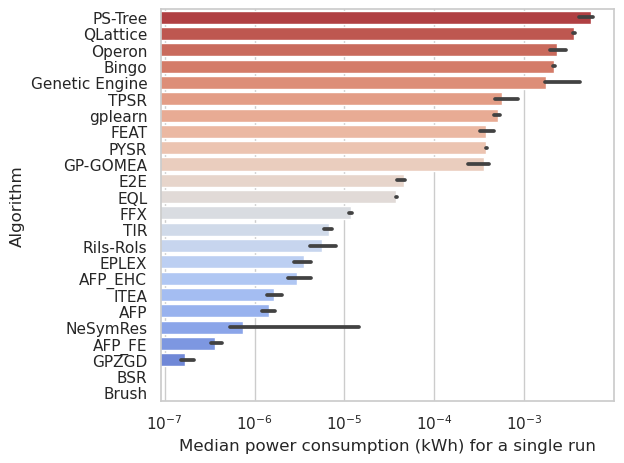

In [8]:
df_eco2ai_filter = df_eco2ai[df_eco2ai['algorithm'].isin([ 'BSR', 'uDSR',
    'AFP', 'AFP_EHC', 'AFP_FE', 'Bingo', 'Brush', 'E2E', 
    'EPLEX', 'EQL', 'FEAT', 'FFX', 'Genetic Engine',
    'GP-GOMEA', 'gplearn', 'GPZGD', 'ITEA', 'NeSymRes', 'Operon',
    'PS-Tree', 'PYSR', 'QLattice', 'Rils-Rols', 'TIR', 'TPSR' 
])]

order = df_eco2ai_filter.groupby('algorithm').median() \
              .sort_values('power_consumption(kWh)', ascending=False).index

sns.barplot(data=df_eco2ai_filter, y='algorithm', x='power_consumption(kWh)', order=order, estimator=np.median, palette='coolwarm_r')
#plt.xticks(rotation=90, ha='right')
plt.xlabel("Median power consumption (kWh) for a single run")
plt.ylabel("Algorithm")
plt.xscale('log')
save('power_consumption(kWh)')
plt.show()

/tmp/ipykernel_597571/3013283303.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order = df_eco2ai.groupby('algorithm').sum() \


saving ../figs/black-box-tuning//total_power_consumption(kWh).pdf


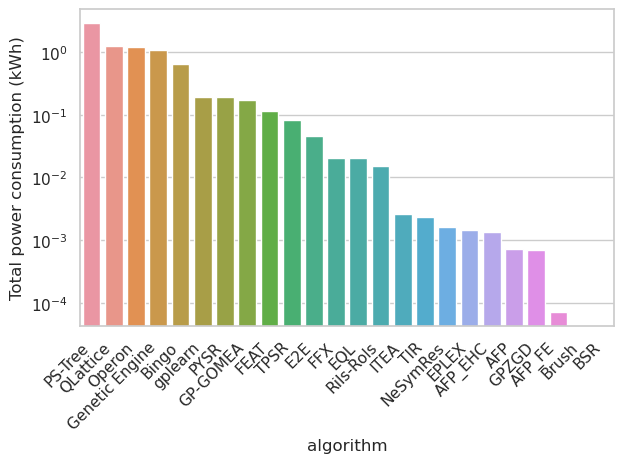

In [9]:
order = df_eco2ai.groupby('algorithm').sum() \
              .sort_values('power_consumption(kWh)', ascending=False).index
              
sns.barplot(data=df_eco2ai.groupby('algorithm').sum(numeric_only=True).reset_index(),
            x='algorithm', y='power_consumption(kWh)', order=order)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total power consumption (kWh)')
plt.yscale('log')
save('total_power_consumption(kWh)')
plt.show()

In [10]:
# We are going to merge with final results so we can have training time information as well
df_results = pd.read_feather(rdir+'results.feather')

df_results = pd.merge(
    left=df_eco2ai, 
    right=df_results,
    how='left',
    left_on=['dataset', 'algorithm', 'random_state'],
    right_on=['dataset', 'algorithm', 'random_state'],
)

print(df_results.shape)
print(df_results.columns)

df_results2 = df_results.merge(df_results.groupby('dataset')['algorithm'].nunique().reset_index(),
                              on='dataset',suffixes=('','_count'))

                                       
# rankings per trial per dataset
for col in [c for c in df_results2.columns if c.endswith('test') or c.endswith('size')]:
    ascending = 'r2' not in col
    df_results2[col+'_rank_per_trial']=df_results2.groupby(['dataset','random_state'])[col].apply(lambda x: 
                                                                              round(x,3).rank(
                                                                              ascending=ascending))
    
df_sum = df_results2.groupby(['algorithm','dataset'],as_index=False).median()
df_sum['rmse_test'] = df_sum['mse_test'].apply(np.sqrt)
df_sum['log_mse_test'] = df_sum['mse_test'].apply(lambda x: np.log(1+x))
    
df_results = df_results2

# rankings and normalized scores per dataset
for col in [c for c in df_sum.columns if c.endswith('test') or c.endswith('size')]:
    ascending = 'r2' not in col
    df_sum[col+'_rank']=df_sum.groupby(['dataset'])[col].apply(lambda x: 
                                                                        round(x,3).rank(ascending=ascending)
                                                                  )
    df_sum[col+'_norm'] = df_sum.groupby('dataset')[col].apply(lambda x: (x-x.min())/(x.max()-x.min()))

(7427, 33)
Index(['dataset', 'algorithm', 'random_state', 'start_time',
       'experiment_description', 'duration(s)', 'power_consumption(kWh)',
       'CO2_emissions(kg)', 'CPU_name', 'GPU_name', 'cost', 'symbolic_alg_x',
       'pre_trained_x', 'gp_alg_x', 'training time (s)', 'symbolic_model',
       'mse_test', 'mae_test', 'r2_test', 'model_size', 'params_str',
       'training time (hr)', 'symbolic_alg_y', 'pre_trained_y', 'gp_alg_y',
       'r2_zero_test', 'friedman_dataset', 'algorithm_count',
       'mse_test_rank_per_trial', 'mae_test_rank_per_trial',
       'r2_test_rank_per_trial', 'model_size_rank_per_trial',
       'r2_zero_test_rank_per_trial'],
      dtype='object')


/tmp/ipykernel_597571/4047316831.py:22: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df_results2[col+'_rank_per_trial']=df_results2.groupby(['dataset','random_state'])[col].apply(lambda x:
/tmp/ipykernel_597571/4047316831.py:22: FutureWarning: Not prepending group keys to the result index of transform-like apply. In the future, the group keys will be included in the index, regardless of whether the applied function returns a like-indexed object.
To preserve the previous behavior, use

	>>> .groupby(..., group_keys=False)

To adopt the future behavior and silence this warning, use 

	>>> .groupby(..., group_keys=True)
  df_results2[col+'_ra

/tmp/ipykernel_597571/4180338715.py:10: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order_kwh = df_sum_filter.groupby('algorithm').median() \
/tmp/ipykernel_597571/4180338715.py:13: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  order_time = df_sum_filter.groupby('algorithm').median() \
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/seaborn/_statistics.py:486: RuntimeWarning: All-NaN slice encountered
  estimate = self.estimator(vals)
/home/ch246537/.conda/envs/srbench-brush-cpp/lib/python3.9/site-packages/seaborn/algorithms.py:98: RuntimeWarning: All-NaN slice encountered
  b

saving ../figs/black-box-tuning//time_and_power_consumption(kWh).pdf


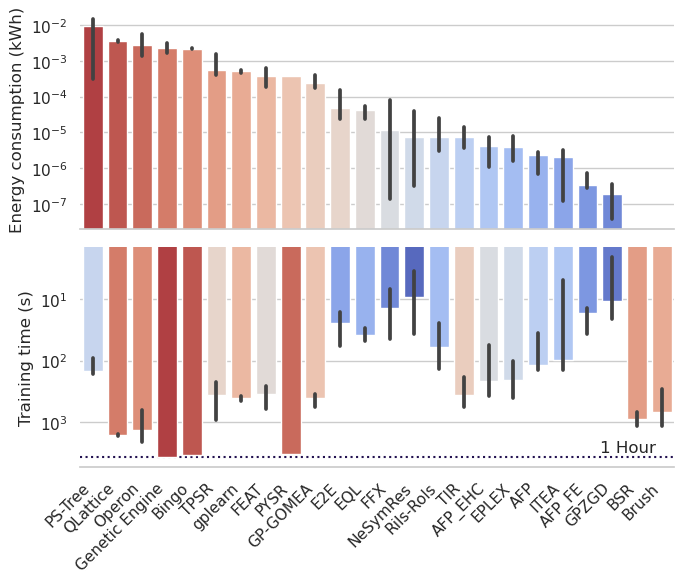

In [11]:
import matplotlib as mpl

df_sum_filter = df_sum[df_sum['algorithm'].isin([ 'BSR', 'uDSR',
    'AFP', 'AFP_EHC', 'AFP_FE', 'Bingo', 'Brush', 'E2E', 
    'EPLEX', 'EQL', 'FEAT', 'FFX', 'Genetic Engine',
    'GP-GOMEA', 'gplearn', 'GPZGD', 'ITEA', 'NeSymRes', 'Operon',
    'PS-Tree', 'PYSR', 'QLattice', 'Rils-Rols', 'TIR', 'TPSR' 
])]

order_kwh = df_sum_filter.groupby('algorithm').median() \
              .sort_values('power_consumption(kWh)', ascending=False).index

order_time = df_sum_filter.groupby('algorithm').median() \
              .sort_values('training time (s)', ascending=False).index

palette = sns.color_palette('coolwarm_r', n_colors=len(order_kwh))

fig, axes = plt.subplots(figsize=(7,6), nrows=2, sharex=True)

sns.barplot(data=df_sum_filter, x='algorithm', y='power_consumption(kWh)', ax=axes[0], order=order_kwh, estimator=np.nanmedian, palette=dict(zip(order_kwh, palette)))
axes[0].set_ylabel("Energy consumption (kWh)")
axes[0].set_xlabel("")
axes[0].set_yscale('log')

sns.barplot(data=df_sum_filter, x='algorithm', y='training time (s)', ax=axes[1], order=order_kwh, estimator=np.nanmedian, palette=dict(zip(order_time, palette)))
axes[1].set_ylabel("Training time (s)")
axes[1].set_xlabel("")
axes[1].set_yscale('log')
axes[1].axhline(3600, zorder=-999, ls=':')
axes[1].text(len(order_kwh)-3.5, 3000, '1 Hour')

axes[1].invert_yaxis() 

plt.xticks(rotation=45, ha='right')

sns.despine(left=True)
fig.tight_layout()

save('time_and_power_consumption(kWh)')
plt.show()